Imports

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import copy
from torchsummary import summary

In [25]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Using CPU')

Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU


Dataset Paths for OUR MASTER dataset

In [26]:
train_dir = r"C:\SUTD\50.021 Artificial Intelligence\pppppp\Master_Dataset\train"
val_dir = r"C:\SUTD\50.021 Artificial Intelligence\pppppp\Master_Dataset\val"
test_dir = r"C:\SUTD\50.021 Artificial Intelligence\pppppp\Master_Dataset\test"

Transforms

In [27]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


DataLoaders

In [28]:
# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Train class_to_idx:", train_dataset.class_to_idx)
print("Val class_to_idx:", val_dataset.class_to_idx)
print("Test class_to_idx:", test_dataset.class_to_idx)

Classes: ['NORMAL', 'PNEUMONIA']
Train size: 14054
Val size: 1757
Test size: 1757
Train class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}
Val class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}
Test class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}


ALEXNET MODEL

In [29]:
def build_alexnet():
    model = models.alexnet(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(),
        nn.Linear(9216, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Linear(1024, 512),
        nn.ReLU(inplace=True),
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, 32),
        nn.ReLU(inplace=True),
        nn.Linear(32, 2)
    )
    return model

RESNET18 MODEL

In [30]:
def build_resnet18():
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(),
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, 32),
        nn.ReLU(inplace=True),
        nn.Linear(32, 2),
        nn.ReLU(inplace=True)
    )
    return model

Load Models

In [31]:
def load_model(model_name, path, device):
    if model_name == "alexnet":
        model = build_alexnet()
    elif model_name == "resnet18":
        model = build_resnet18()
    else:
        raise ValueError("Unknown model name")

    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

In [32]:
criterion = nn.CrossEntropyLoss()

alexnet_model = load_model("alexnet", "alexnet_finetuned_baseline.pth", device)
resnet_model = load_model("resnet18", "resnet18_finetuned_baseline.pth", device)

C:\Users\thoai\AppData\Local\Temp\ipykernel_18096\4156658993.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location=device)


FGSM attack

In [33]:
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

x_min = (0.0 - mean) / std
x_max = (1.0 - mean) / std
# --- FGSM ---
def fgsm_attack(x, epsilon, grad, x_min, x_max):
    x_adv = x + epsilon * grad.sign()
    x_adv = torch.max(torch.min(x_adv, x_max), x_min)
    return x_adv

# --- Evaluation loop ---
def evaluate_fgsm(model, loader, epsilon):
    loss_fn = nn.CrossEntropyLoss()
    correct_clean = 0
    correct_adv   = 0
    total         = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        images.requires_grad = True

        # Clean accuracy
        out = model(images)
        correct_clean += (out.argmax(1) == labels).sum().item()

        # Compute gradient w.r.t. input
        loss = loss_fn(out, labels) # FIX: Use out.logits here
        model.zero_grad()
        loss.backward()

        # Perturb and re-evaluate
        adv_images = fgsm_attack(images, epsilon, images.grad.data, x_min, x_max)
        with torch.no_grad():
            adv_out = model(adv_images)
        correct_adv += (adv_out.argmax(1) == labels).sum().item()

        total += labels.size(0)

    clean_acc = 100 * correct_clean / total
    adv_acc   = 100 * correct_adv   / total
    print(f"ε={epsilon:.3f} | Clean acc: {clean_acc:.1f}%  Adv acc: {adv_acc:.1f}%  "
          f"Drop: {clean_acc - adv_acc:.1f}%")
    return clean_acc, adv_acc

Run FGSM from eps 0.01 to 0.1 for AlexNet

In [34]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
alexnet_results = [evaluate_fgsm(alexnet_model, test_loader, eps)[1] for eps in epsilons]

ε=0.000 | Clean acc: 77.9%  Adv acc: 77.9%  Drop: 0.0%
ε=0.010 | Clean acc: 77.9%  Adv acc: 10.5%  Drop: 67.4%
ε=0.030 | Clean acc: 77.9%  Adv acc: 1.2%  Drop: 76.7%
ε=0.050 | Clean acc: 77.9%  Adv acc: 0.5%  Drop: 77.4%
ε=0.100 | Clean acc: 77.9%  Adv acc: 1.5%  Drop: 76.4%


Run FGSM from eps 0.01 to 0.1 for ResNet-18

In [35]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
resnet_results = [
    evaluate_fgsm(resnet_model, test_loader, eps)[1]
    for eps in epsilons
]


ε=0.000 | Clean acc: 75.3%  Adv acc: 75.3%  Drop: 0.0%
ε=0.010 | Clean acc: 75.3%  Adv acc: 23.8%  Drop: 51.5%
ε=0.030 | Clean acc: 75.3%  Adv acc: 40.8%  Drop: 34.5%
ε=0.050 | Clean acc: 75.3%  Adv acc: 43.8%  Drop: 31.5%
ε=0.100 | Clean acc: 75.3%  Adv acc: 51.1%  Drop: 24.2%


In [36]:

print(resnet_results)

[75.2988047808765, 23.790552077404666, 40.75128059191804, 43.82470119521912, 51.10984632896984]


Accuracy vs eps curves for alexnet and resnet

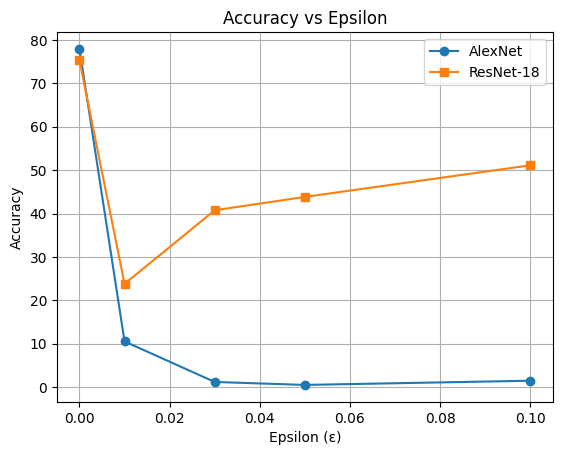

In [37]:
import matplotlib.pyplot as plt

# Plot both curves
plt.plot(epsilons, alexnet_results, marker='o', label='AlexNet')
plt.plot(epsilons, resnet_results, marker='s', label='ResNet-18')

# Labels and title
plt.xlabel('Epsilon (ε)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon')

# Legend
plt.legend()

# Show
plt.grid(True)
plt.show()